## Step 1: Disable all warnings

In [1]:
import warnings
warnings.filterwarnings("ignore")

## Step 2: Import Python packages

In [1]:
import os
import pandas as pd
import openpyxl
import seaborn as sn
import matplotlib.pyplot as plt

## Step 3: Setup working directory

In [2]:
os.chdir('/Users/markruperto/Desktop/School/GCU/BIT-456/Topic 3 - SQL in Python')

In [3]:
os.getcwd()

'/Users/markruperto/Desktop/School/GCU/BIT-456/Topic 3 - SQL in Python'

## Step 4: Load "sqlite3" package and establish connection to database file

In [4]:
import sqlite3
#Loads Python built-in sqlite3

connection = sqlite3.connect('chinook.db')
#Opens a connection to the database

cur = connection.cursor()
#Creates a cursor object from the connection

## Step 5: Retrieve table names from database

In [5]:
TablesList = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';",connection)

print(TablesList)

               name
0            albums
1   sqlite_sequence
2           artists
3         customers
4         employees
5            genres
6          invoices
7     invoice_items
8       media_types
9         playlists
10   playlist_track
11           tracks
12     sqlite_stat1


## Step 6: Define a Python function to count number of rows in a SQL database table

In [6]:
def rowscount(table_name):
    #define function and input "table_name"
    
    cur.execute(f"SELECT COUNT(*) FROM {table_name}")
    #Runs SQL queryu using cursor: counts every row in specified table
    
    count = cur.fetchone()[0]
    #Grabs query results
    
    return count

## Step 7: Define another Python function to update a TablesList dataframe with number of rows in each table

In [7]:
def rowscountable(TablesList, table_name):
    row_count = rowscount(table_name)
    TablesList.loc[TablesList['name'] == table_name, 'RowCount'] = row_count
    return TablesList

## Step 8: Run the "rowscountable" function for each table name

In [8]:
for table in TablesList['name']:
    TablesList = rowscountable(TablesList, table)

print(TablesList)

               name  RowCount
0            albums     347.0
1   sqlite_sequence      10.0
2           artists     275.0
3         customers      59.0
4         employees       8.0
5            genres      25.0
6          invoices     412.0
7     invoice_items    2240.0
8       media_types       5.0
9         playlists      18.0
10   playlist_track    8715.0
11           tracks    3503.0
12     sqlite_stat1      15.0


## Step 9: Create a column chart showing the counts of each table in TablesList

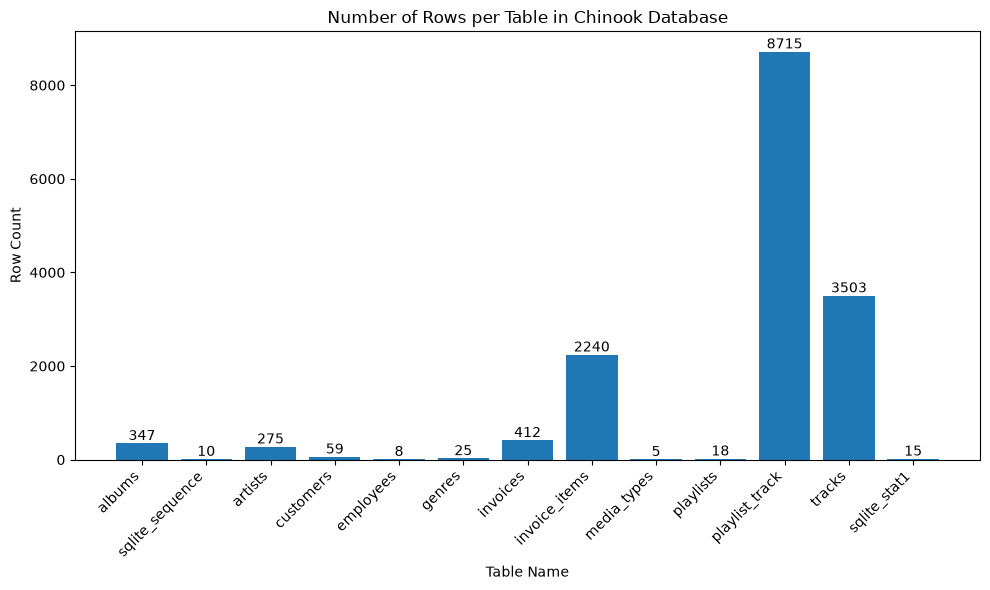

In [9]:
plt.figure(figsize=(10, 6))
bars = plt.bar(TablesList['name'], TablesList['RowCount'])

#Add count values above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, int(height),
              ha='center', va='bottom')

plt.xlabel('Table Name')
plt.ylabel('Row Count')
plt.title('Number of Rows per Table in Chinook Database')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 10: Retrieve records from the "invoices" table and Create histogram

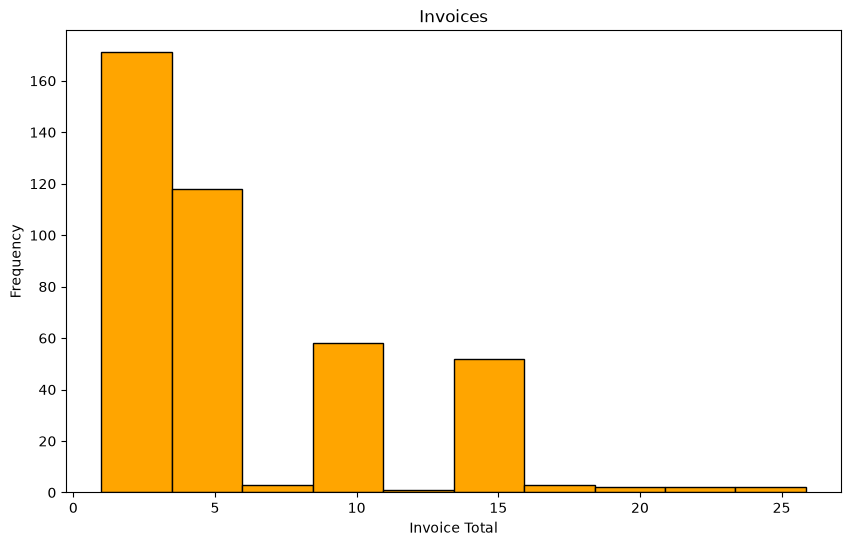

In [10]:
#Retrieve records from the invoices table
Invoices = pd.read_sql_query("SELECT * FROM invoices;", connection)

#Create a histogram of the Total column
plt.figure(figsize=(10, 6))
plt.hist(Invoices['Total'], edgecolor='black', color='orange')

plt.xlabel('Invoice Total')
plt.ylabel('Frequency')
plt.title('Invoices')
plt.show()

## Step 11: Run a SQL query to determine which customers have the most Invoices

In [11]:
query = """
SELECT CustomerId,
       COUNT(InvoiceId) AS TotalInvoices,
       ROUND(SUM(Total), 2) AS TotalAmount,
       BillingCountry
FROM invoices
GROUP BY CustomerId
ORDER BY TotalInvoices DESC;
"""

CustomerInvoices = pd.read_sql_query(query, connection)
print(CustomerInvoices)

    CustomerId  TotalInvoices  TotalAmount  BillingCountry
0            1              7        39.62          Brazil
1            2              7        37.62         Germany
2            3              7        39.62          Canada
3            4              7        39.62          Norway
4            5              7        40.62  Czech Republic
5            6              7        49.62  Czech Republic
6            7              7        42.62         Austria
7            8              7        37.62         Belgium
8            9              7        37.62         Denmark
9           10              7        37.62          Brazil
10          11              7        37.62          Brazil
11          12              7        37.62          Brazil
12          13              7        37.62          Brazil
13          14              7        37.62          Canada
14          15              7        38.62          Canada
15          16              7        37.62             U

## Step 12: Run a SQL query to determine which artists have released the most albums

In [12]:
query = """
SELECT Name AS ArtistName,
       (SELECT COUNT(*) FROM albums WHERE albums.ArtistId = artists.ArtistId) AS AlbumCount
FROM artists
ORDER BY AlbumCount DESC
LIMIT 12;
"""

AlbumsCount = pd.read_sql_query(query, connection)
print(AlbumsCount)

         ArtistName  AlbumCount
0       Iron Maiden          21
1      Led Zeppelin          14
2       Deep Purple          11
3         Metallica          10
4                U2          10
5     Ozzy Osbourne           6
6         Pearl Jam           5
7   Various Artists           4
8     Faith No More           4
9      Foo Fighters           4
10             Lost           4
11        Van Halen           4


## Step 13: Run a SQL query to determine the counts of genre by media type

In [13]:
query = """
SELECT genres.Name AS GenreName,
       media_types.Name AS MediaType,
       COUNT(*) AS GenreCount
FROM tracks
JOIN genres ON tracks.GenreId = genres.GenreId
JOIN media_types ON tracks.MediaTypeId = media_types.MediaTypeId
GROUP BY genres.Name, media_types.Name
ORDER BY GenreCount DESC;
"""

GenreCount = pd.read_sql_query(query, connection)
print(GenreCount)

             GenreName                    MediaType  GenreCount
0                 Rock              MPEG audio file        1211
1                Latin              MPEG audio file         578
2                Metal              MPEG audio file         374
3   Alternative & Punk              MPEG audio file         332
4                 Jazz              MPEG audio file         127
5             TV Shows  Protected MPEG-4 video file          93
6                 Rock     Protected AAC audio file          84
7                Blues              MPEG audio file          81
8            Classical     Protected AAC audio file          67
9                Drama  Protected MPEG-4 video file          64
10              Reggae              MPEG audio file          58
11            R&B/Soul              MPEG audio file          49
12          Soundtrack              MPEG audio file          42
13         Alternative     Protected AAC audio file          38
14         Hip Hop/Rap              MPEG

## Step 14: Create a cross tabulation based on the information in GenreCount

In [14]:
GenreCountCrosstab = pd.crosstab(
    index=GenreCount['GenreName'],
    columns=GenreCount['MediaType'],
    values=GenreCount['GenreCount'],
    aggfunc='sum',
    margins=True,
    margins_name='Total'
)

print(GenreCountCrosstab)

MediaType           AAC audio file  MPEG audio file  Protected AAC audio file  \
GenreName                                                                       
Alternative                    NaN              NaN                      38.0   
Alternative & Punk             NaN            332.0                       NaN   
Blues                          NaN             81.0                       NaN   
Bossa Nova                     NaN             15.0                       NaN   
Classical                      1.0              NaN                      67.0   
Comedy                         NaN              NaN                       NaN   
Drama                          NaN              NaN                       NaN   
Easy Listening                 NaN             24.0                       NaN   
Electronica/Dance              2.0             28.0                       NaN   
Heavy Metal                    NaN             28.0                       NaN   
Hip Hop/Rap                 

## Step 15: Export the GenreCountCrosstab dataframe to an Excel file

In [15]:
GenreCountCrosstab.to_excel('GenreCountCrosstab.xlsx', sheet_name='report', index=True)

## Step 16: Close the connection to the "chinook.db"

In [17]:
connection.close()

## Step 17: Re-enable warning

In [18]:
warnings.simplefilter('always')